In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(r'C:\Users\nagaraj nalla\Downloads\Employee\Notebooks\Employee Attrition.csv')

In [5]:
df.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59598 entries, 0 to 59597
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee ID               59598 non-null  int64 
 1   Age                       59598 non-null  int64 
 2   Gender                    59598 non-null  object
 3   Years at Company          59598 non-null  int64 
 4   Job Role                  59598 non-null  object
 5   Monthly Income            59598 non-null  int64 
 6   Work-Life Balance         59598 non-null  object
 7   Job Satisfaction          59598 non-null  object
 8   Performance Rating        59598 non-null  object
 9   Number of Promotions      59598 non-null  int64 
 10  Overtime                  59598 non-null  object
 11  Distance from Home        59598 non-null  int64 
 12  Education Level           59598 non-null  object
 13  Marital Status            59598 non-null  object
 14  Number of Dependents  

In [ ]:
df['Company Tenure'].value_counts()

,count
Company Tenure,
55,820
50,802
65,802
52,795
43,791
...,...
124,11
125,10
126,6


In [ ]:
df.dtypes

,0
Employee ID,int64
Age,int64
Gender,object
Years at Company,int64
Job Role,object
Monthly Income,int64
Work-Life Balance,object
Job Satisfaction,object
Performance Rating,object
Number of Promotions,int64


In [ ]:
df.isnull().sum()

,0
Employee ID,0
Age,0
Gender,0
Years at Company,0
Job Role,0
Monthly Income,0
Work-Life Balance,0
Job Satisfaction,0
Performance Rating,0
Number of Promotions,0


In [ ]:
df.drop(columns=['Employee ID']).describe(include='number')

,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Number of Dependents,Company Tenure
count,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000
mean,38.565875,15.753901,7302.397983,0.832578,50.007651,1.648075,55.758415
std,12.079673,11.245981,2151.457423,0.994991,28.466459,1.555689,25.411090
min,18.000000,1.000000,1316.000000,0.000000,1.000000,0.000000,2.000000
25%,28.000000,7.000000,5658.000000,0.000000,25.000000,0.000000,36.000000
50%,39.000000,13.000000,7354.000000,1.000000,50.000000,1.000000,56.000000
75%,49.000000,23.000000,8880.000000,2.000000,75.000000,3.000000,76.000000
max,59.000000,51.000000,16149.000000,4.000000,99.000000,6.000000,128.000000


In [6]:
df['Job Role'].value_counts()

Job Role
Technology    15507
Healthcare    13642
Education     12490
Media          9574
Finance        8385
Name: count, dtype: int64

In [ ]:
df.describe(include='object')

,Gender,Job Role,Work-Life Balance,Job Satisfaction,Performance Rating,Overtime,Education Level,Marital Status,Job Level,Company Size,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
count,59598,59598,59598,59598,59598,59598,59598,59598,59598,59598,59598,59598,59598,59598,59598,59598
unique,2,5,4,4,4,2,5,3,3,3,2,2,2,4,4,2
top,Male,Technology,Good,High,Average,No,Bachelor’s Degree,Married,Entry,Medium,No,No,No,Good,Low,Stayed
freq,32739,15507,22528,29779,35810,40148,17826,29908,23867,29745,48239,56680,49895,29766,23758,31260


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Attrition'].value_counts()

,count
Attrition,
Stayed,31260
Left,28338


In [ ]:
df['Attrition'].value_counts(normalize=True) * 100

,proportion
Attrition,
Stayed,52.451425
Left,47.548575


In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include="object").columns

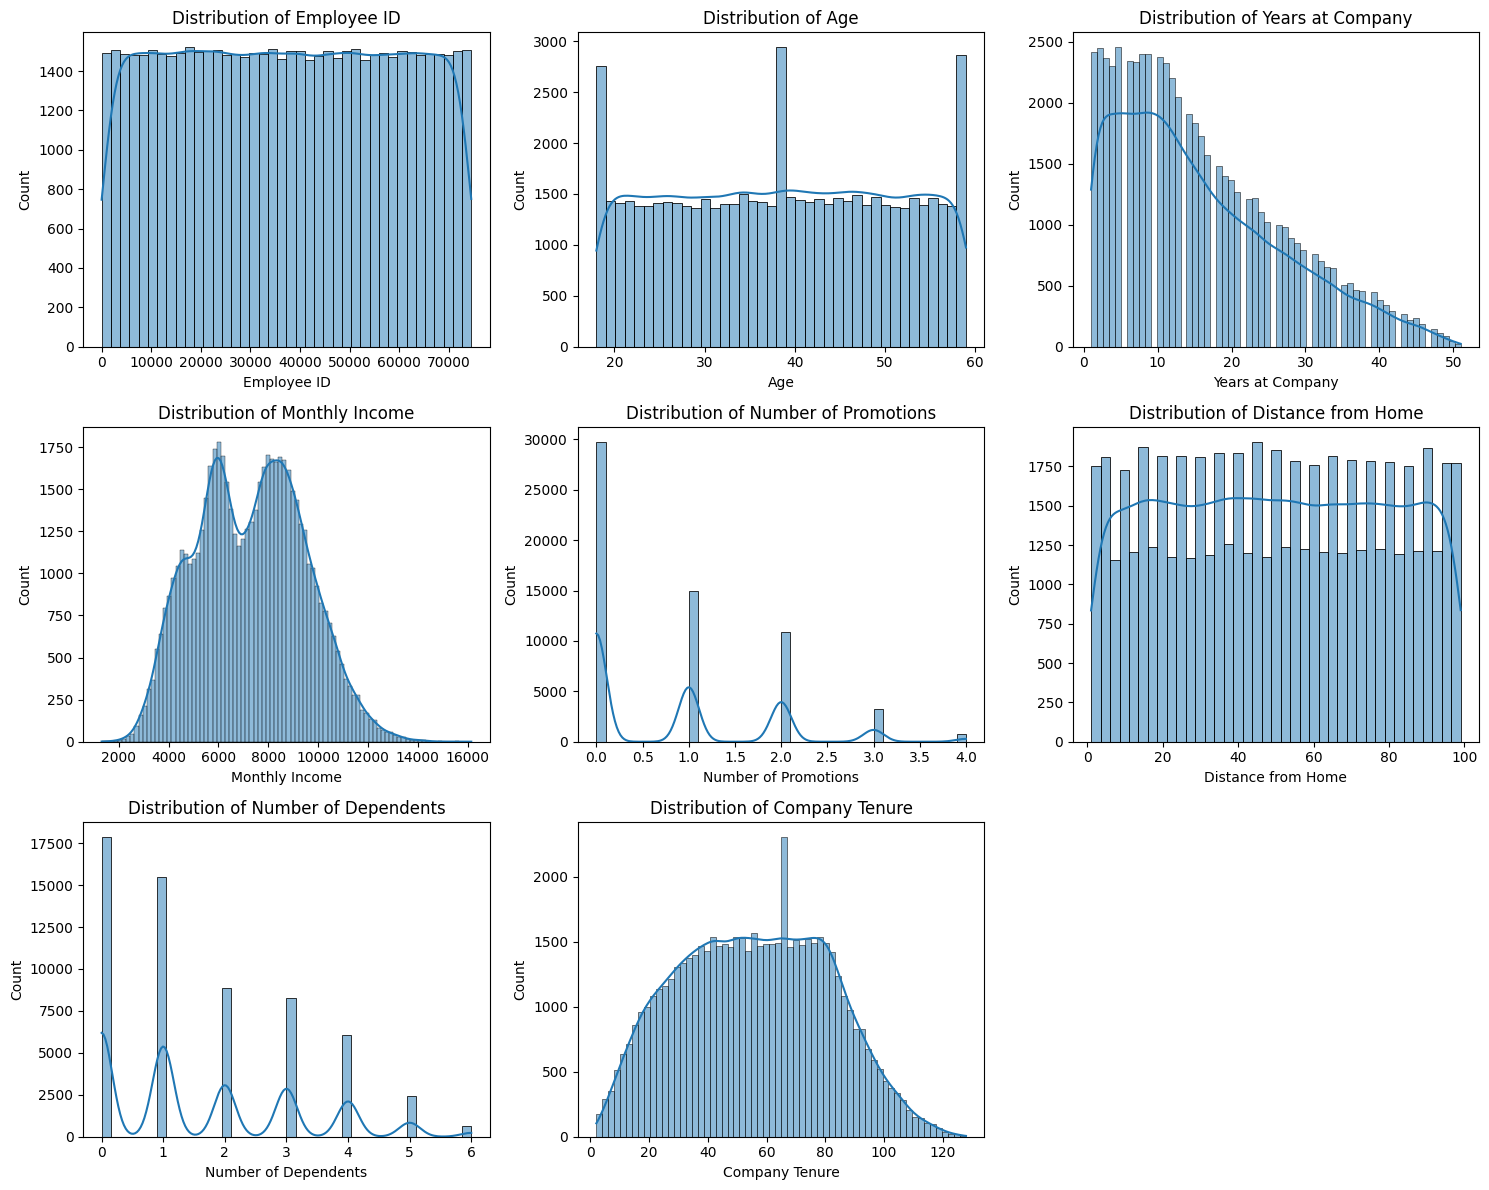

In [ ]:
import math

n_cols = 3
n_rows = math.ceil(len(numerical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))

axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

# Remove unused plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

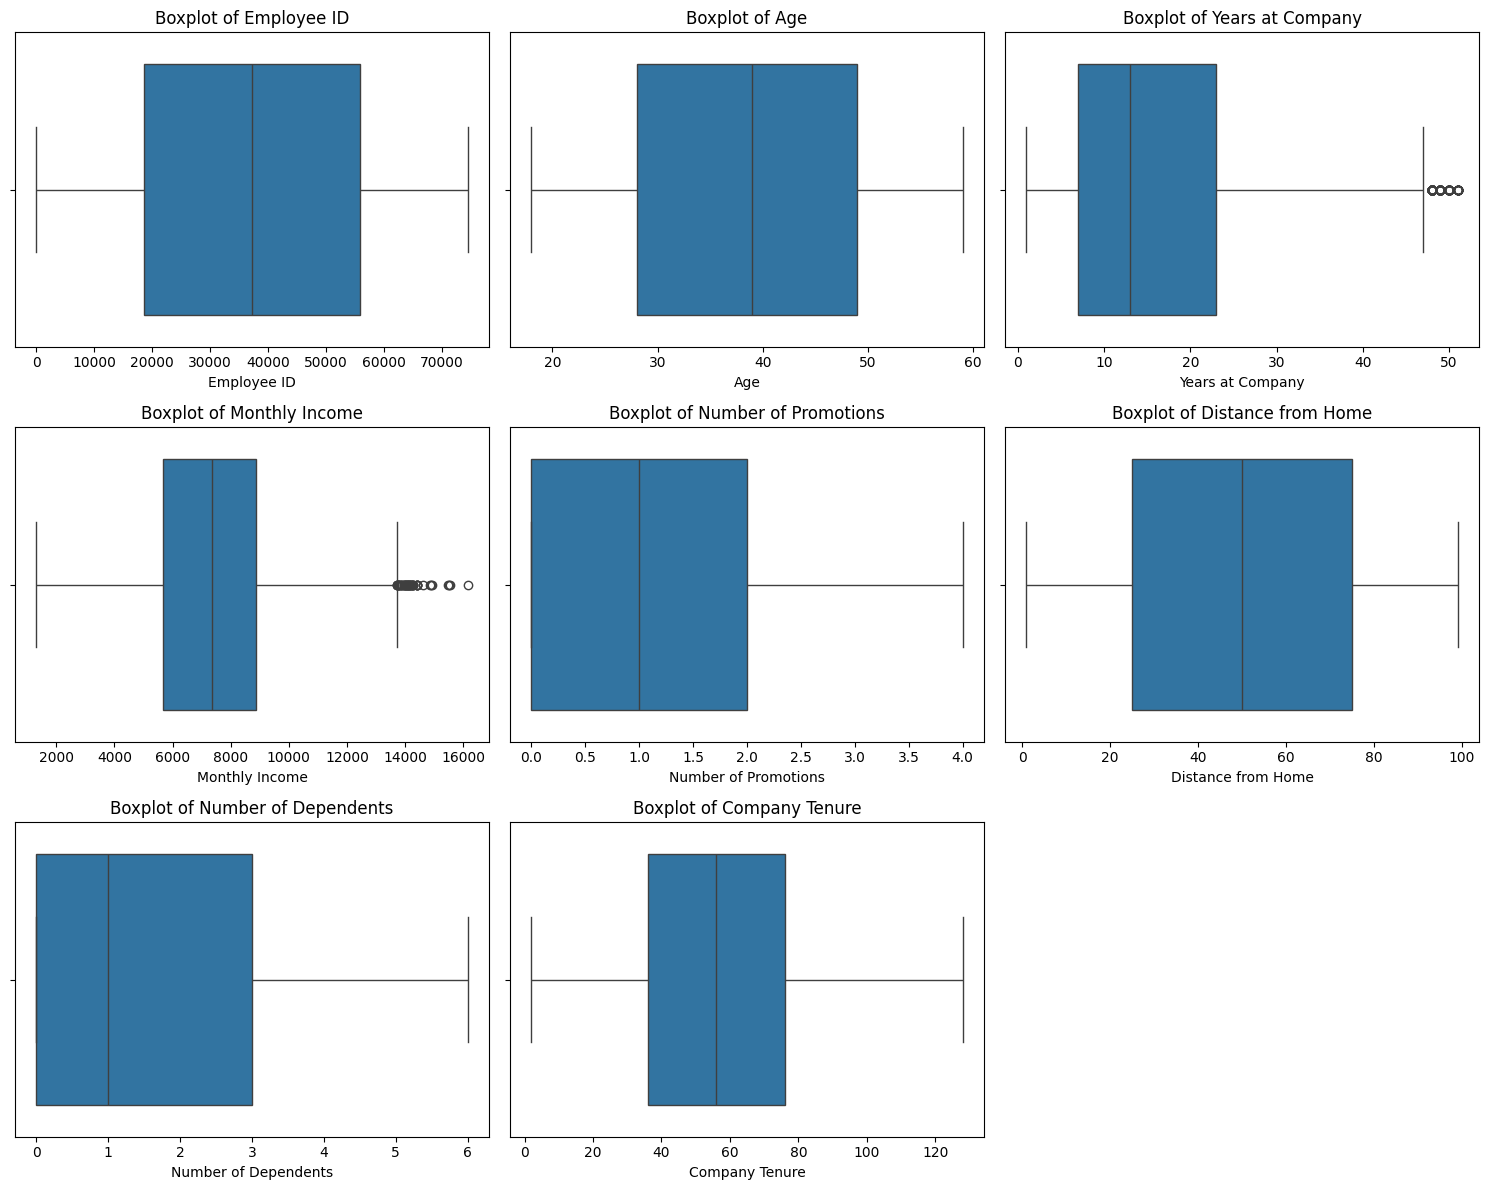

In [ ]:
n_cols = 3
n_rows = math.ceil(len(numerical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))

axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")

# Remove unused plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
outlier_summary = []

for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        'Column': col,
        'Outliers': outliers,
        'Percentage': outliers / len(df) * 100
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df

,Column,Outliers,Percentage
0,Employee ID,0,0.000000
1,Age,0,0.000000
2,Years at Company,273,0.458069
3,Monthly Income,50,0.083895
4,Number of Promotions,0,0.000000
5,Distance from Home,0,0.000000
6,Number of Dependents,0,0.000000
7,Company Tenure,0,0.000000


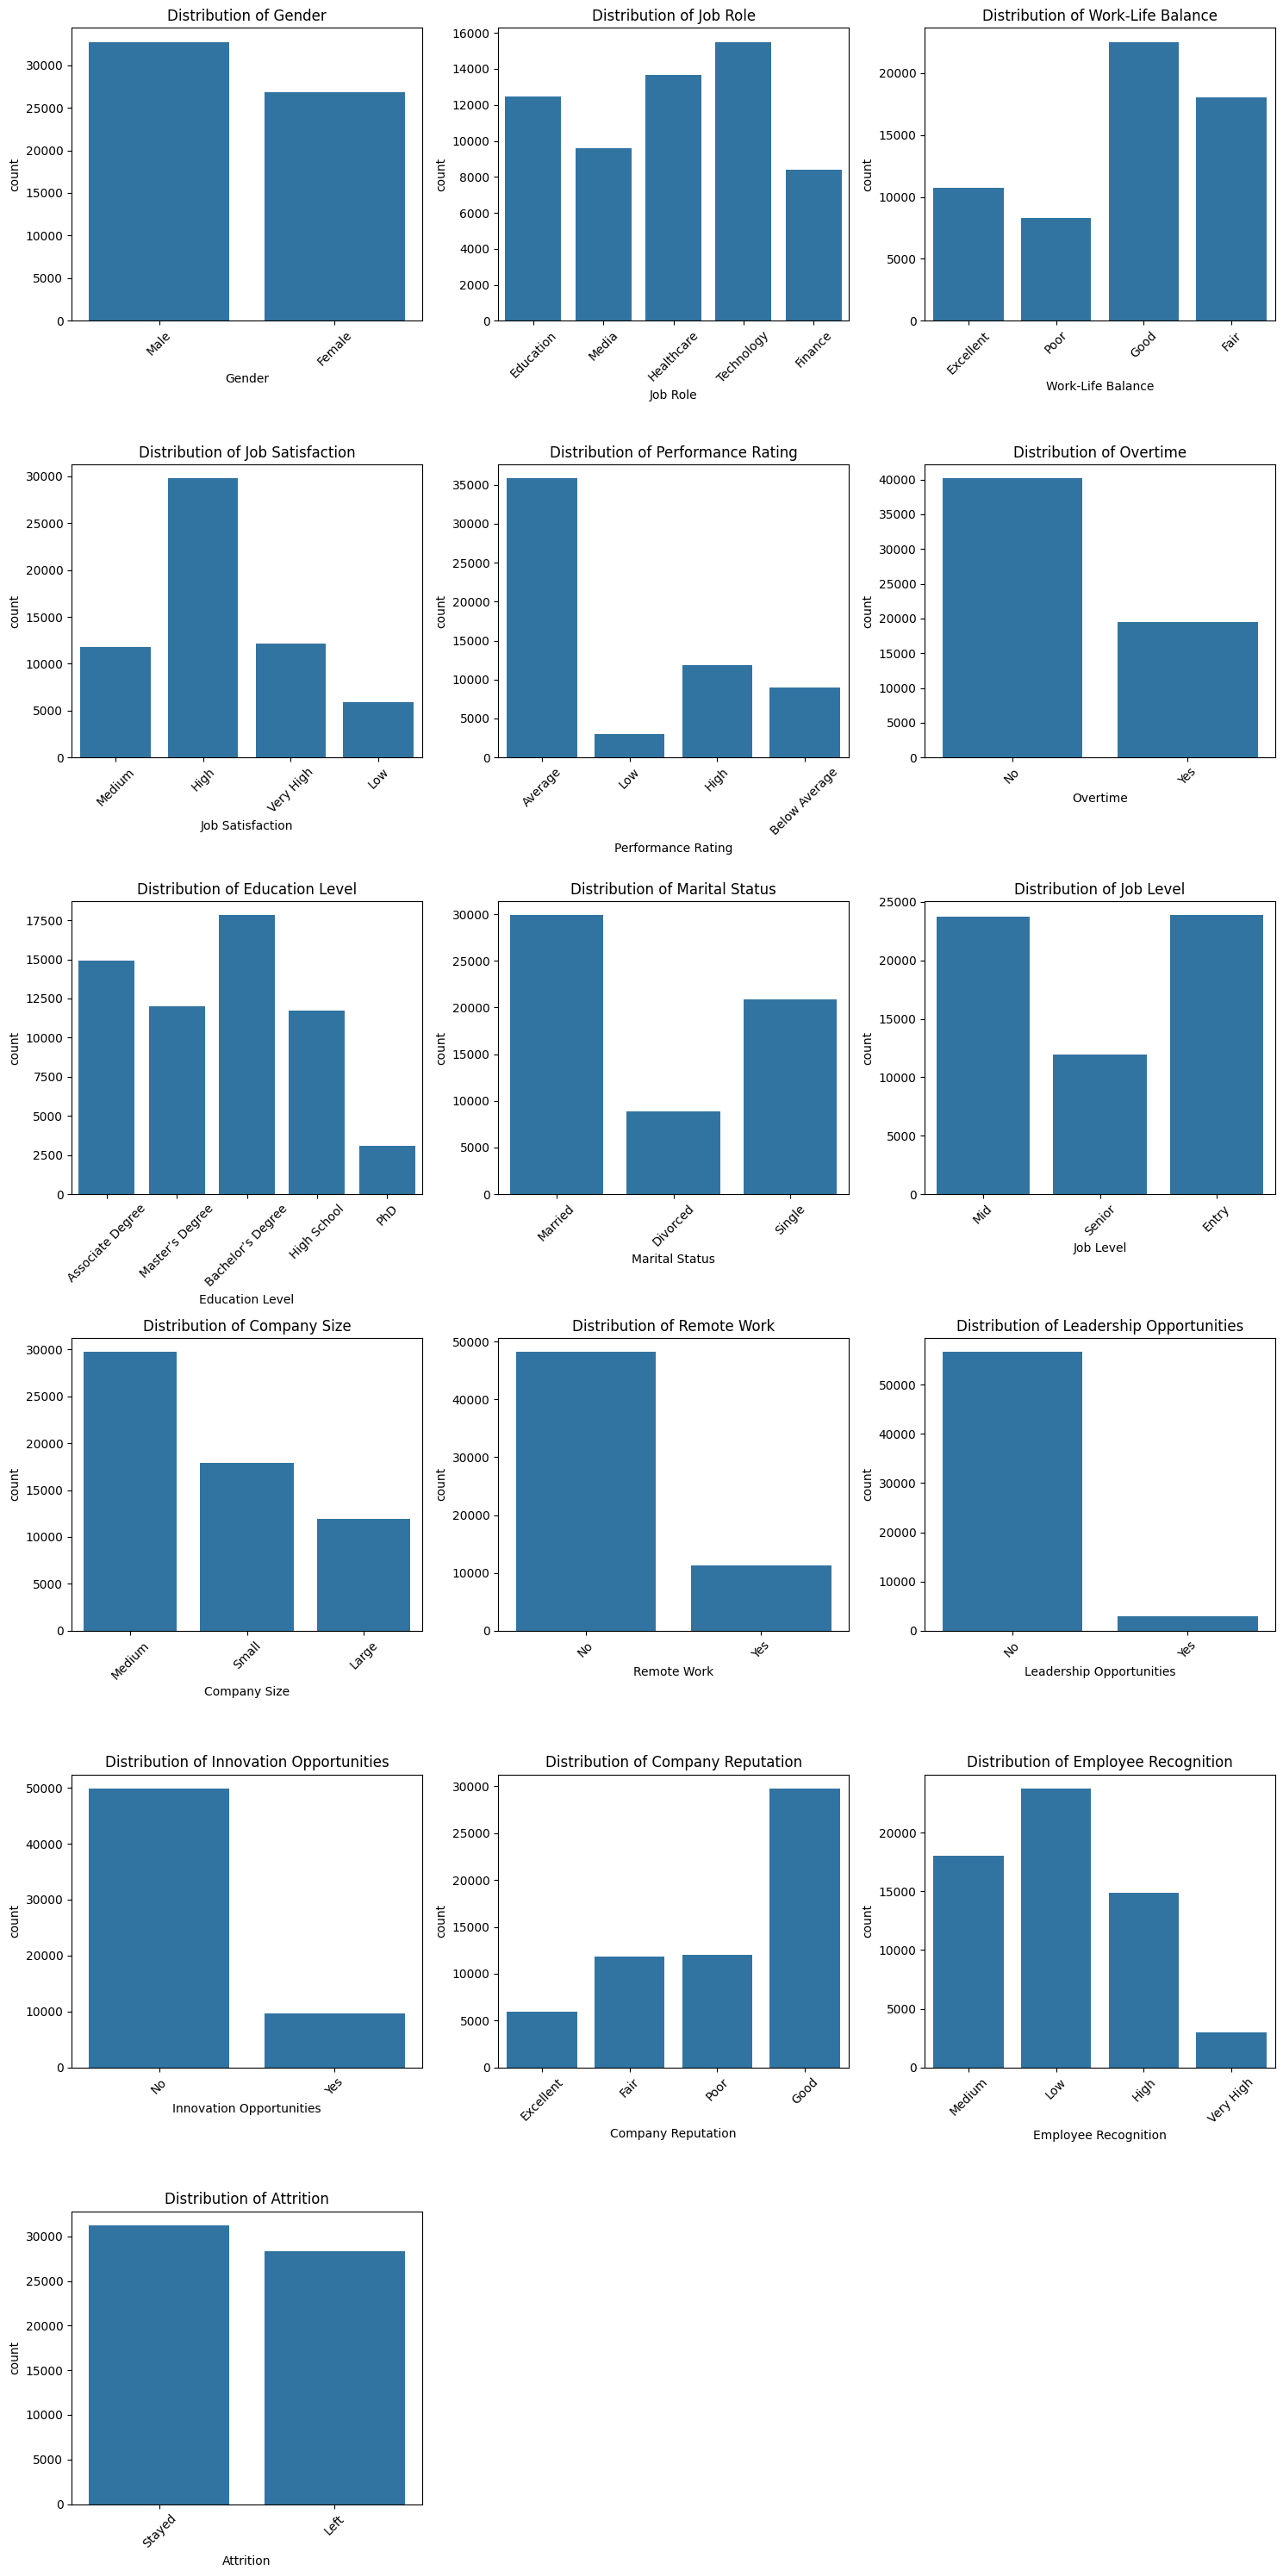

In [ ]:
n_cols = 3
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 5 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].tick_params(axis='x', rotation=45)

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
for col in categorical_cols:
    attrition_pct = pd.crosstab(
        df[col],
        df['Attrition'],
        normalize='index'
    ) * 100

    print(f"\n{'='*50}")
    print(f"Attrition Percentage by {col}")
    print(f"{'='*50}")
    print(attrition_pct.round(2))


Attrition Percentage by Gender
Attrition   Left  Stayed
Gender                  
Female     53.16   46.84
Male       42.94   57.06

Attrition Percentage by Job Role
Attrition    Left  Stayed
Job Role                 
Education   48.72   51.28
Finance     46.80   53.20
Healthcare  47.31   52.69
Media       47.44   52.56
Technology  47.29   52.71

Attrition Percentage by Work-Life Balance
Attrition           Left  Stayed
Work-Life Balance               
Excellent          35.81   64.19
Fair               57.46   42.54
Good               40.56   59.44
Poor               60.11   39.89

Attrition Percentage by Job Satisfaction
Attrition          Left  Stayed
Job Satisfaction               
High              45.30   54.70
Low               52.42   47.58
Medium            45.32   54.68
Very High         52.89   47.11

Attrition Percentage by Performance Rating
Attrition            Left  Stayed
Performance Rating               
Average             46.15   53.85
Below Average       51.81   48.

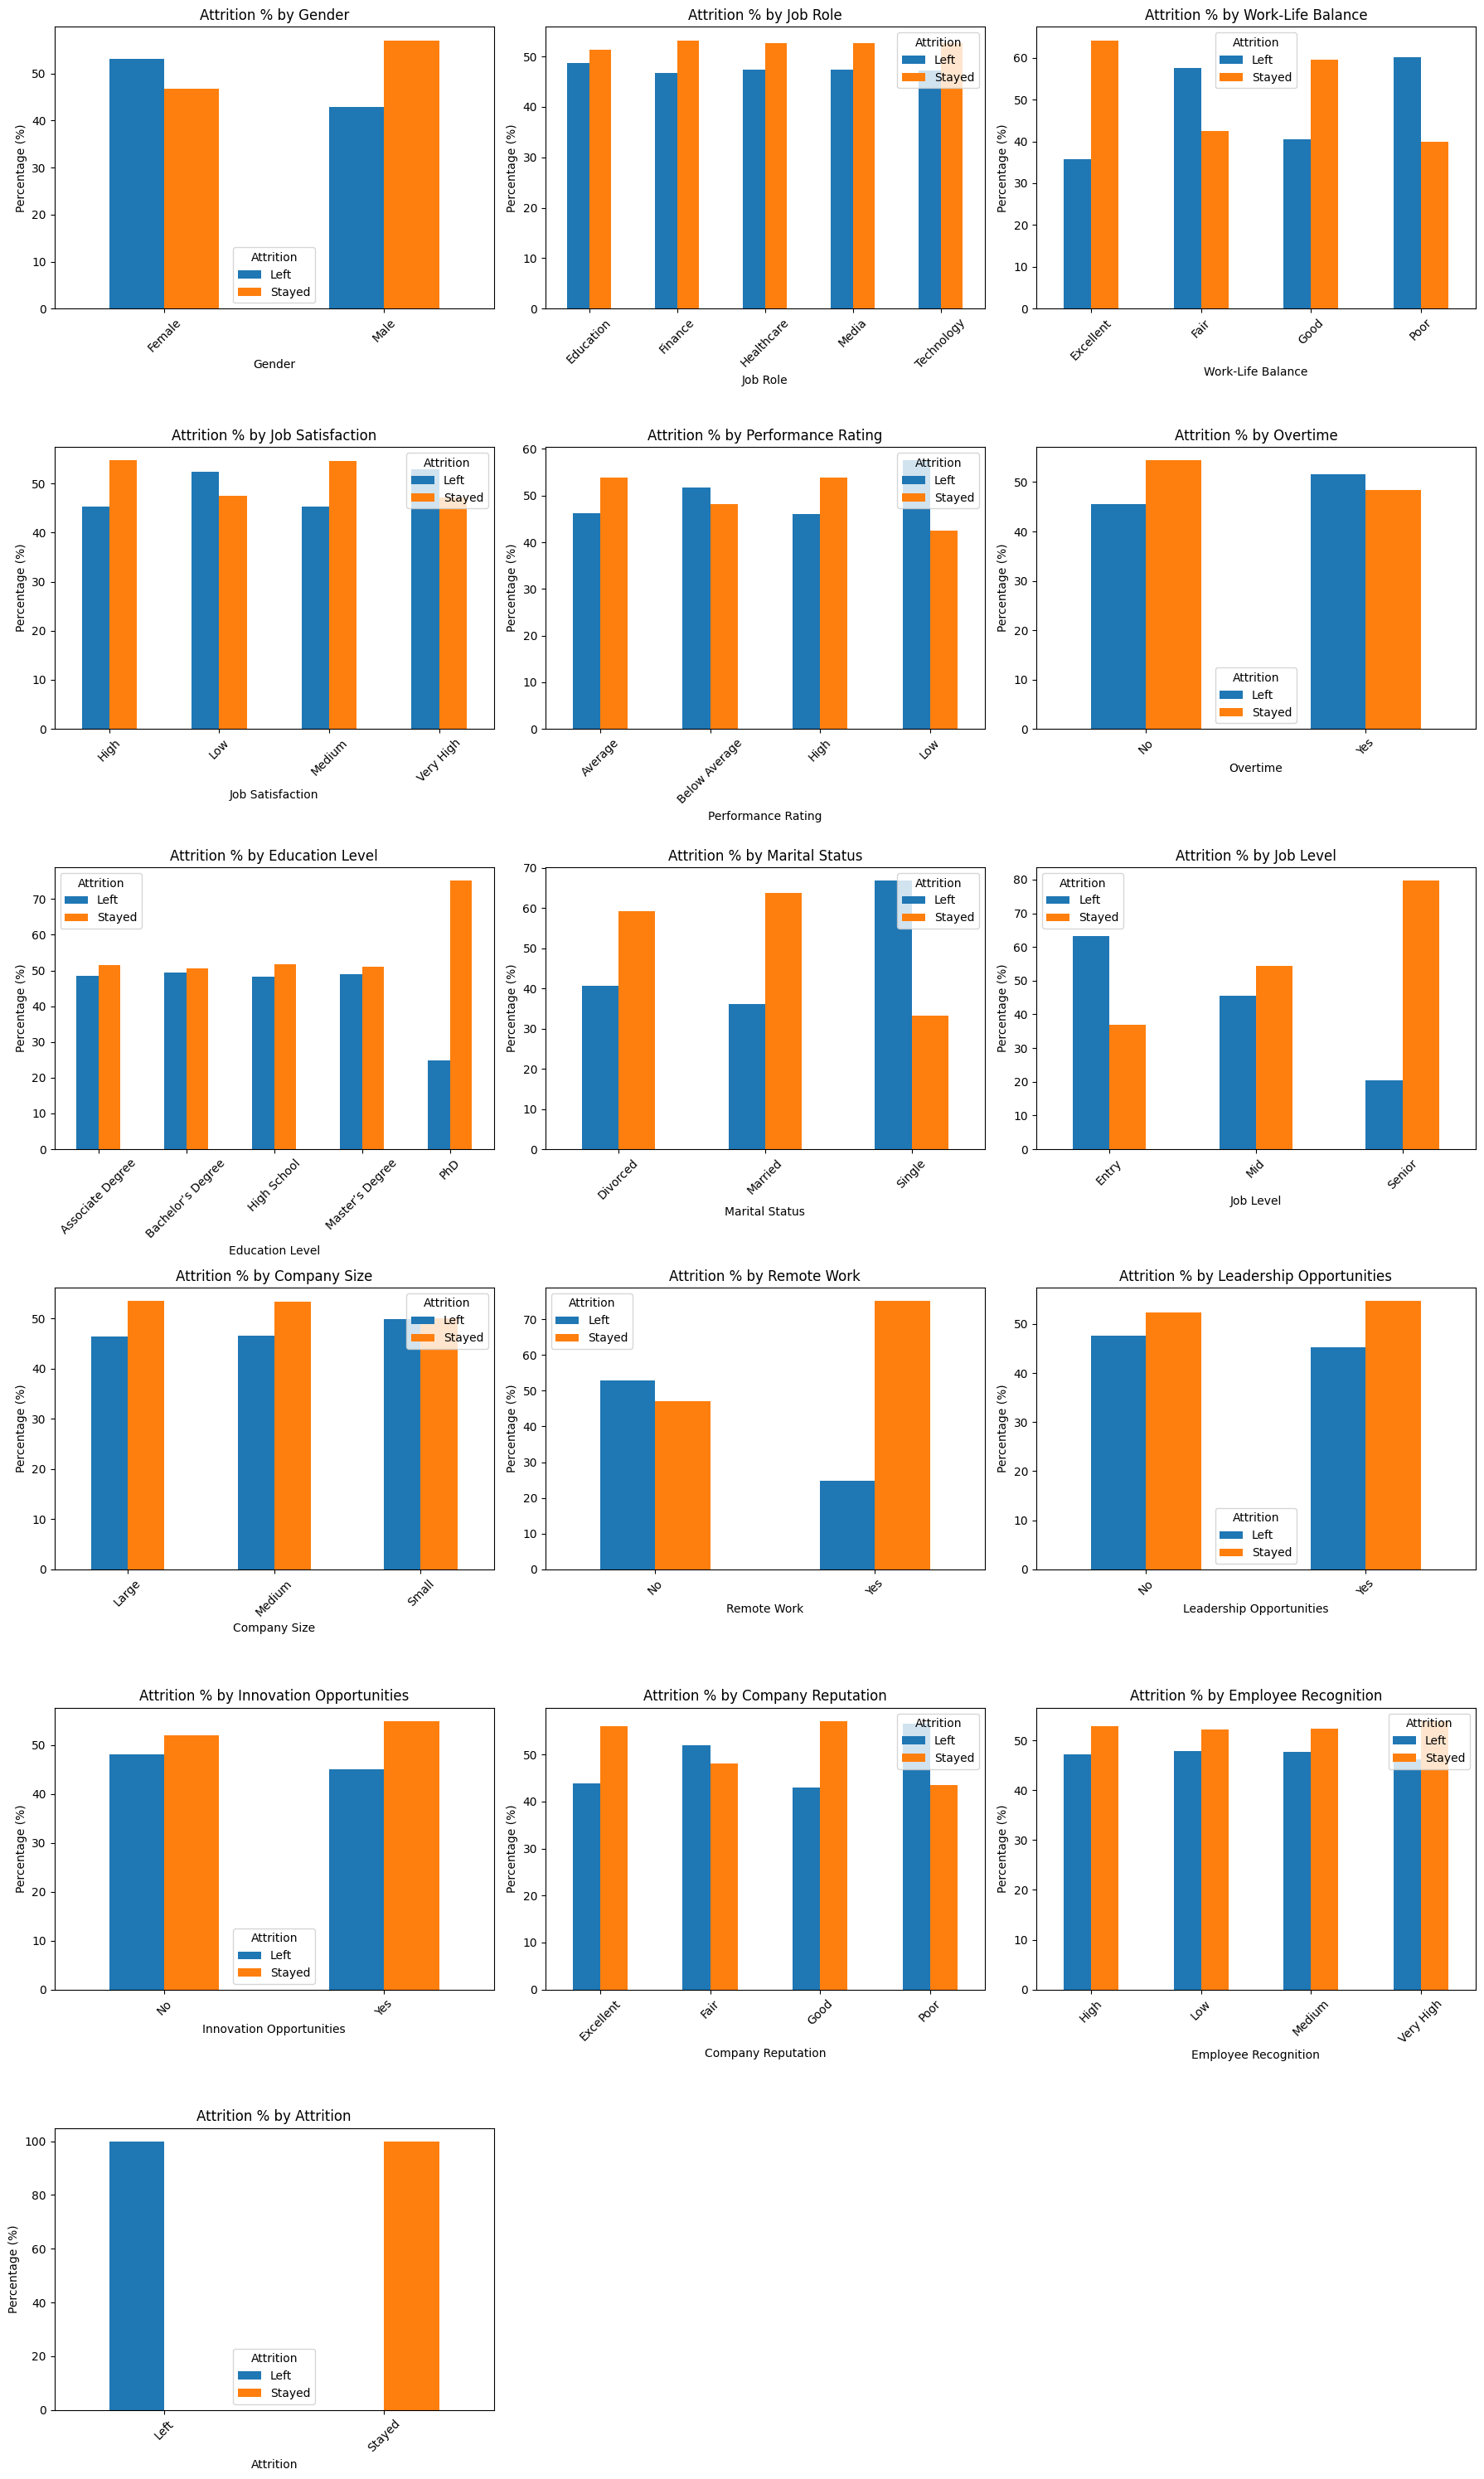

In [ ]:
n_cols = 3
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(categorical_cols):

    # Calculate percentage
    attrition_pct = pd.crosstab(
        df[col],
        df['Attrition'],
        normalize='index'
    ) * 100

    # Plot
    attrition_pct.plot(
        kind='bar',
        ax=axes[i]
    )

    axes[i].set_title(f"Attrition % by {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Percentage (%)")
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title="Attrition")

# Remove unused plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

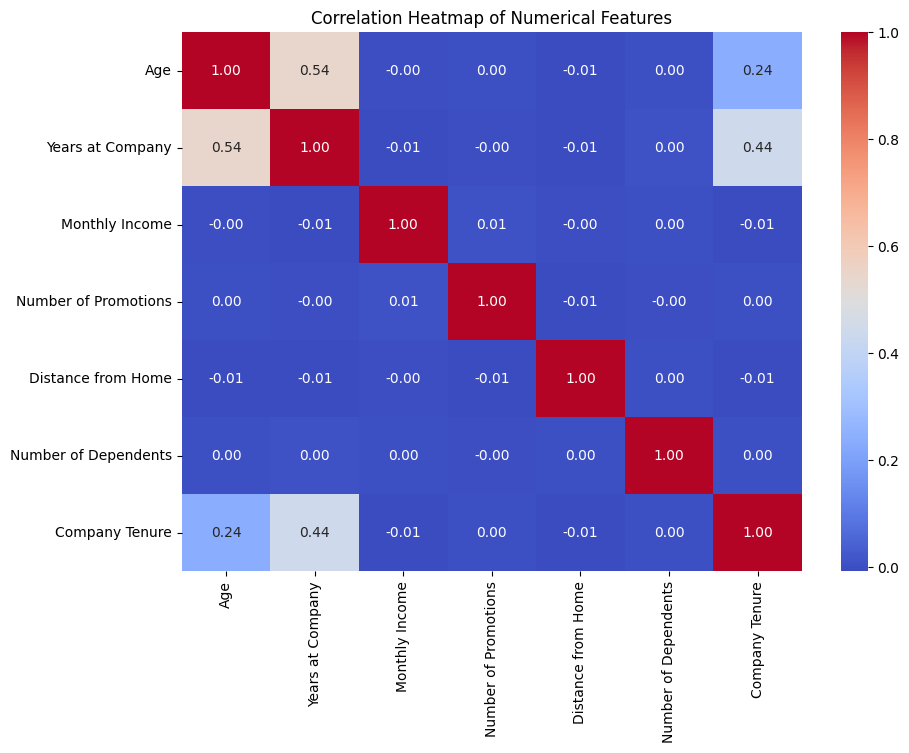

In [ ]:
num_cols = df.select_dtypes(include='number').columns.drop('Employee ID')

corr = df[num_cols].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numerical Features')
plt.show()

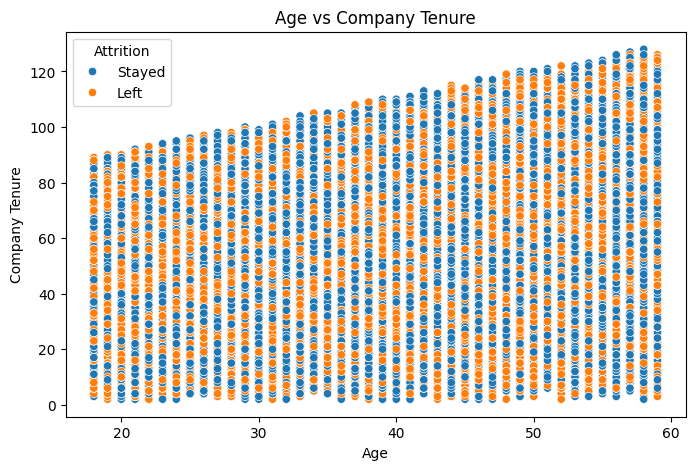

In [ ]:
#Age v/s Company tenure
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Age',
    y='Company Tenure',hue="Attrition"
)

plt.title('Age vs Company Tenure')
plt.xlabel('Age')
plt.ylabel('Company Tenure')

plt.show()

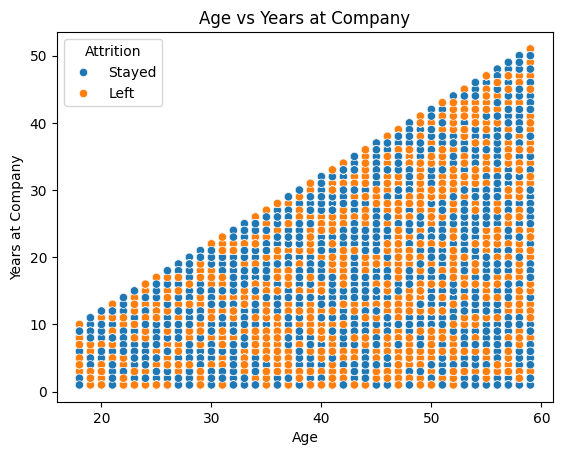

In [ ]:
#Age vs Years at Company
sns.scatterplot(
    data=df,
    x='Age',
    y='Years at Company',hue="Attrition"
)

plt.title('Age vs Years at Company')
plt.xlabel('Age')
plt.ylabel('Years at Company')
plt.show()

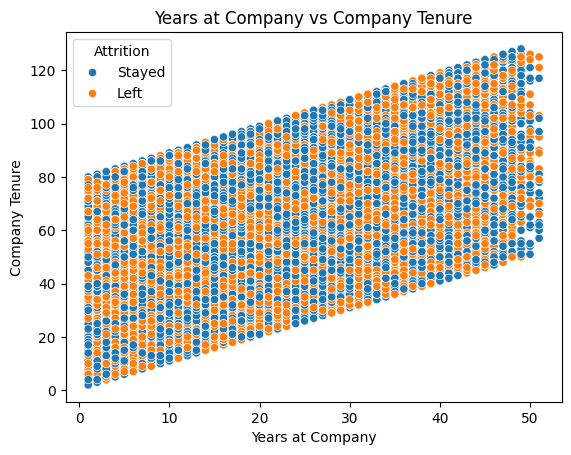

In [ ]:
#Years at Company vs Company Tenure
sns.scatterplot(
    data=df,
    x='Years at Company',
    y='Company Tenure',hue="Attrition"
)

plt.title('Years at Company vs Company Tenure')
plt.xlabel('Years at Company')
plt.ylabel('Company Tenure')
plt.show()

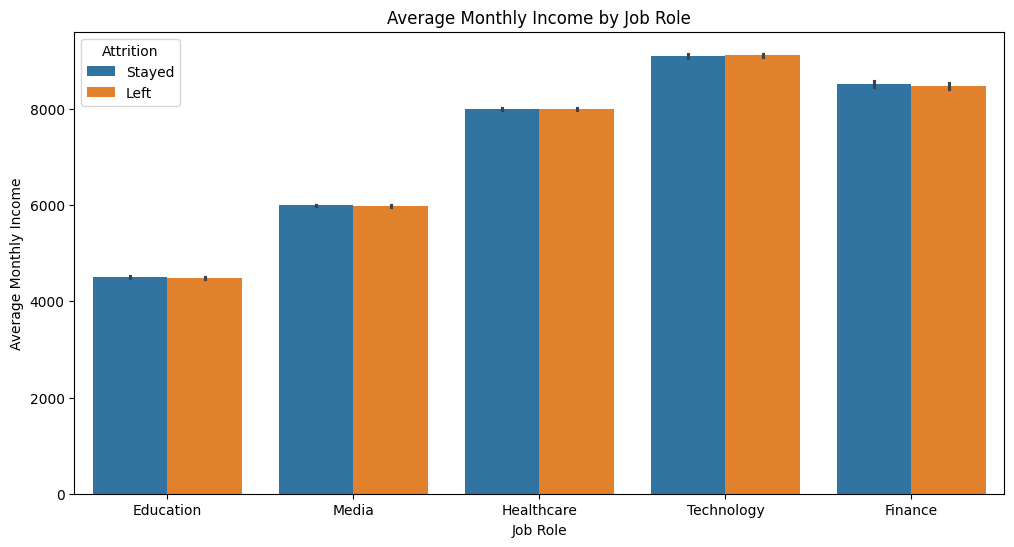

In [ ]:
#JobRole V/s monthly income
plt.figure(figsize=(12, 6))

sns.barplot(
    data=df,
    x='Job Role',
    hue='Attrition',
    y='Monthly Income',
    estimator='mean'
)

plt.title('Average Monthly Income by Job Role')
plt.xlabel('Job Role')
plt.ylabel('Average Monthly Income')
plt.show()

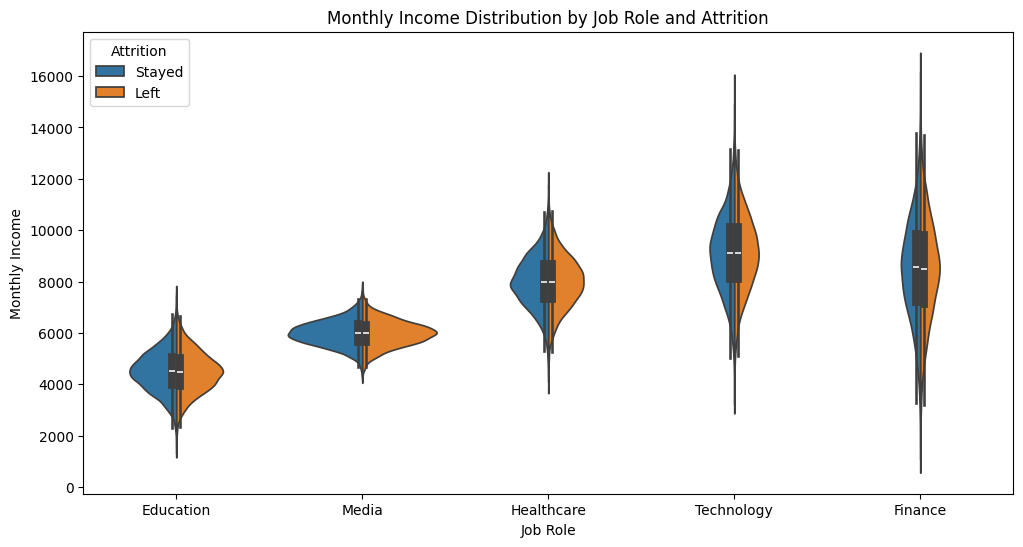

In [ ]:
plt.figure(figsize=(12, 6))

sns.violinplot(
    data=df,
    x='Job Role',
    y='Monthly Income',
    hue='Attrition',
    split=True
)

plt.title('Monthly Income Distribution by Job Role and Attrition')
plt.xlabel('Job Role')
plt.ylabel('Monthly Income')
plt.show()

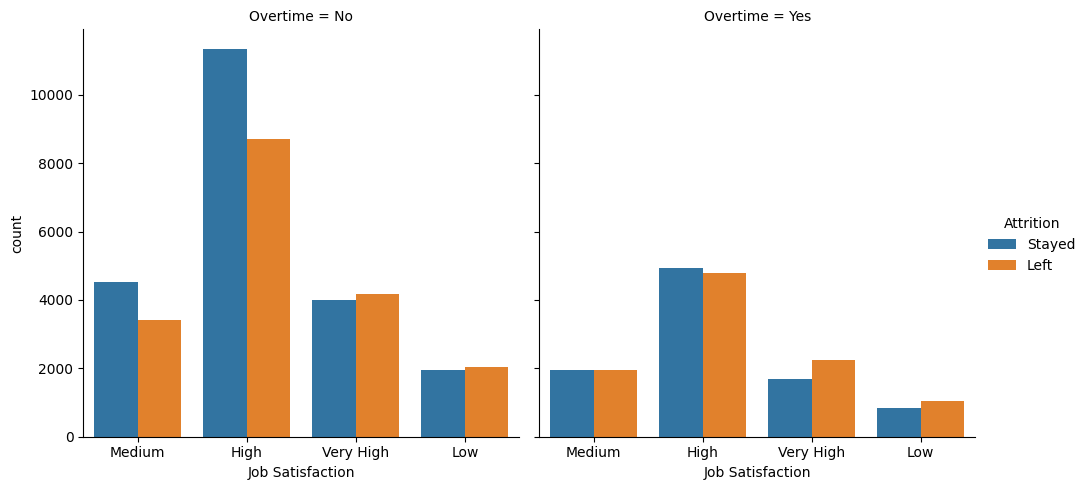

In [ ]:
#overtime vs job satisfaction vs attrition

sns.catplot(
    data=df,
    x="Job Satisfaction",
    hue="Attrition",
    col="Overtime",
    kind="count",
    height=5,
    aspect=1
)

plt.show()

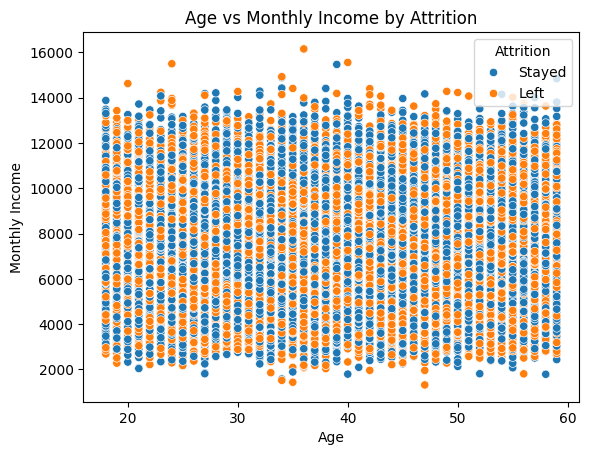

In [ ]:
sns.scatterplot(
    data=df,
    x="Age",
    y="Monthly Income",
    hue="Attrition"
)

plt.title("Age vs Monthly Income by Attrition")

plt.show()

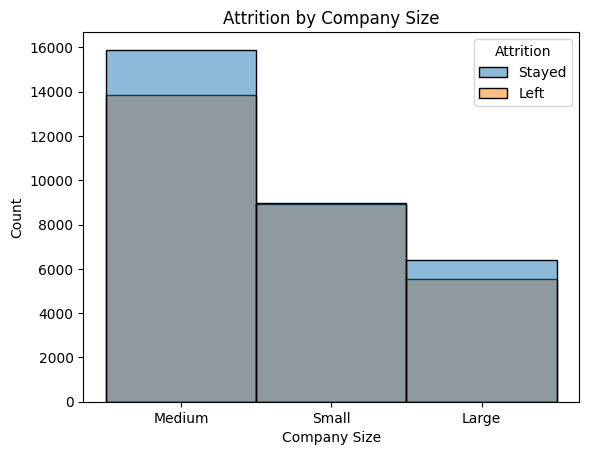

In [ ]:
plt.title('Attrition by Company Size')
sns.histplot(data=df,x=df['Company Size'],hue='Attrition')
plt.show()

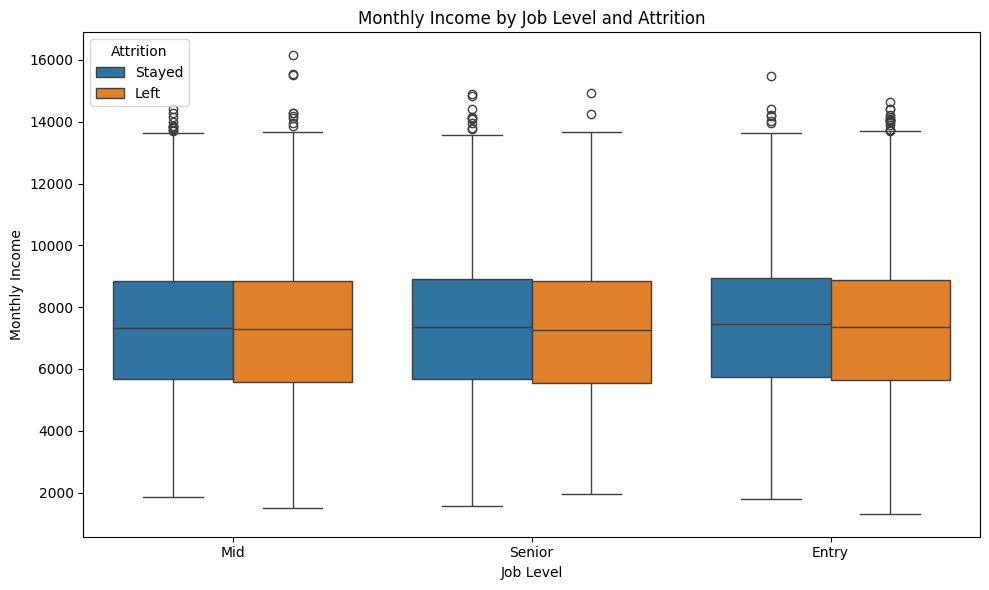

In [ ]:
#Job Level-MonthlyIncome-Attrition
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='Job Level',
    y='Monthly Income',
    hue='Attrition'
)

plt.title('Monthly Income by Job Level and Attrition')
plt.xlabel('Job Level')
plt.ylabel('Monthly Income')

plt.tight_layout()
plt.show()

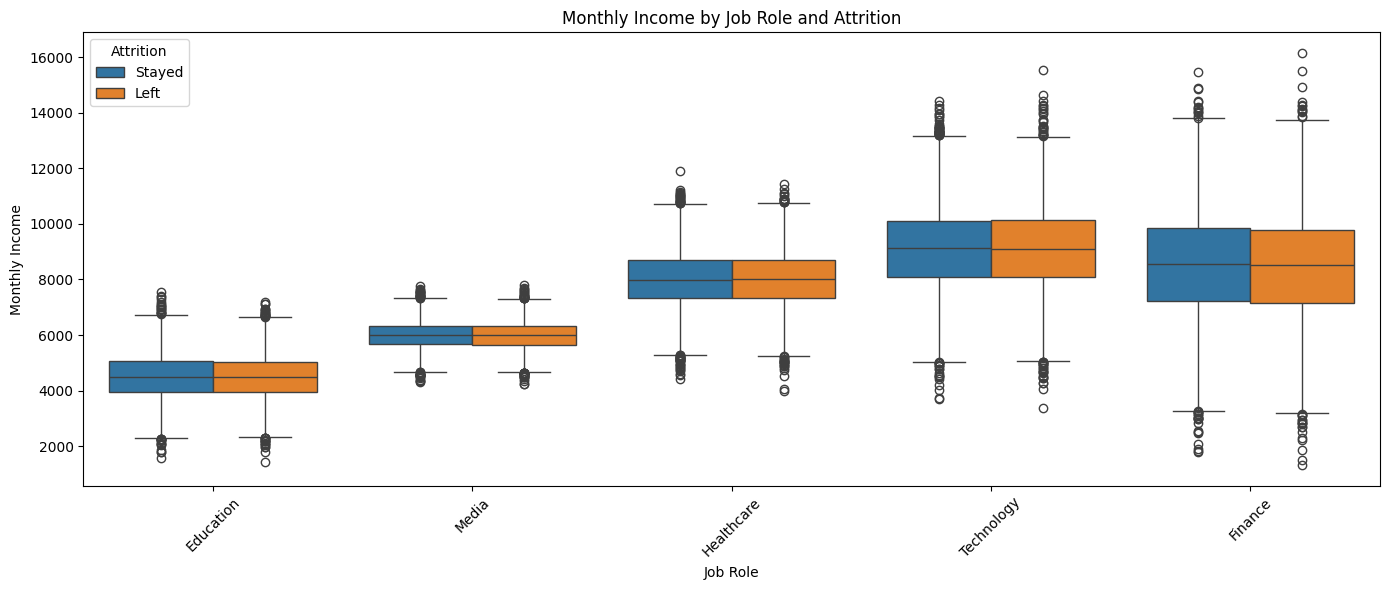

In [ ]:
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df,
    x='Job Role',
    y='Monthly Income',
    hue='Attrition'
)

plt.title('Monthly Income by Job Role and Attrition')
plt.xlabel('Job Role')
plt.ylabel('Monthly Income')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

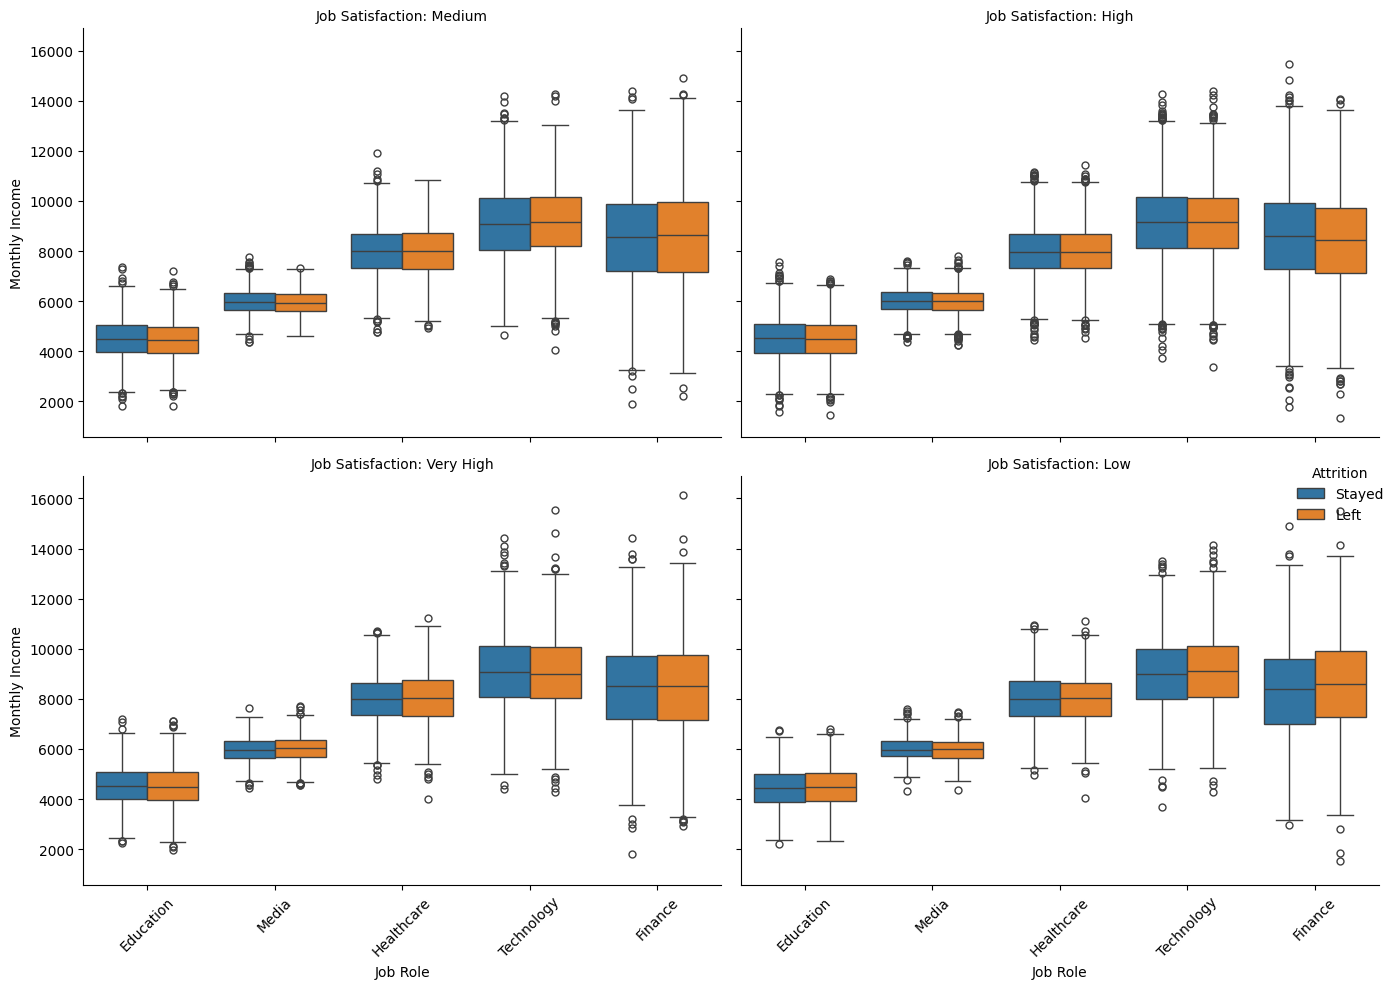

In [ ]:
g = sns.catplot(
    data=df,
    x='Job Role',
    y='Monthly Income',
    hue='Attrition',
    col='Job Satisfaction',
    kind='box',
    col_wrap=2,
    height=5,
    aspect=1.3
)

g.set_axis_labels('Job Role', 'Monthly Income')
g.set_titles('Job Satisfaction: {col_name}')

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#Insights

**Numerical features:**

**Age:** most of the employes are from age group 18,38 and 58 years there are no outliers

**Years at company:** most of the employees have fewer years at company

**monthlyIncome:** monthly income is bimodal distribution indicating there are two highest incomes. the monthly income is having outliers whrere median salary is 7354.

**no. of promotions:** most of the employes are having 0-2 promotions. very less emplys having higher promotions

**distance from home:** the distance is range is same for all employees 20-100km

**no.of dependents:** most of the employees are having 0-2 dependents. few people having 3 and more.

**Company Tenure:** company tenure is normally distributed there is high concentration of tenure around 65-70 months. It ranges approximately from 2 to 128 with a median around 56.



**Categorical Features:**

**Gender:** 54.93% of the employees are males and  45% of the employees are females

**Job Role:** In Technology role has the highest employees followed by healthcare,education, media and finance.

**Work-life Balance:** good is the most common work-life balance category followed by fair, excellent and poor.

**Job Satisfaction:** most of the employees fall under high job satisfaction. and very few employes having very high satisfaction.

**Performance Rating:** most of the employees are performing averagely and very few people having below average.

**Overtime:** most employees are not working overtime. around 32.48% of the employees are working overtime.

**Education Level:** Bachelo's degree is the most common education level followed assosiate,masters.very few people having phd.

**Marital Status:** most of the employees are married followed by single and divorced.

**Job Level:** most of the employees are entry and mid level.20% of the employees are senior level.

1. Age v/s Years at company have the strongest positive relationship.
2. Years at company and company tenure having the moderate positive relationship.

3. Age and company tenure having the weak positive relationship.

4. Technology is having the highest average monthly income around 9100 followed by finance,healthcare, media, education. The employees who left and stayed having same average monthly income.

5. From the violin plots, the monthly income by job role and attrition both the left and stayed employees having the same distributions.

6. Employees who do not work overtime, most of them with high and medium satisfaction stayed.

7. Employees working overtime,for very high and low satisfaction, left people are higher than the stayed.

8. Out of all, the largest group is having high job satisfaction and they are stayed.

9. Age v/s monthly income with attrition are widely spread there is no clear finding of the employee who stayed v/s left.

10. Small-sized companies are having the highest attriton rate followed by small-sized companies.but highest number of employees are leaving from medium-sized companies.

11. Monthly Income v/s Joblevel and attrition, monthly income have similar median values across all job levels and almost same for the left and stayed employees.

12. Different Job roles are having different median incomes, technology having the highest median income and education the lowest.most of the distributions of employees who left and stayed within each role having the almost similar medians.

13. Job role is having the highest effect on income.

14. Employees with the medium satisfaction income differs by jobrole. employees who left and stayed have similar distribution.

15. Employees with low job satisfaction income is not showing a clear difference among the employees who stayed and left.







